In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests


# Reading & Assessing File

In [ ]:
# load data - tips sample dataset
df = pd.read_csv('/assignment_3_viz/toronto_raccoon_activity_index_0401.csv',skiprows=1)

In [22]:
# look at dataset
print(df)
df.head()



                datetime        date  hour  ward_id               ward_name  \
0    2024-01-01 00:00:00  2024-01-01     0        1         Etobicoke North   
1    2024-01-01 00:00:00  2024-01-01     0        2        Etobicoke Centre   
2    2024-01-01 00:00:00  2024-01-01     0        3     Etobicoke-Lakeshore   
3    2024-01-01 00:00:00  2024-01-01     0        4      Parkdale-High Park   
4    2024-01-01 00:00:00  2024-01-01     0        5       York South-Weston   
..                   ...         ...   ...      ...                     ...   
595  2024-01-01 23:00:00  2024-01-01    23       21      Scarborough Centre   
596  2024-01-01 23:00:00  2024-01-01    23       22   Scarborough-Agincourt   
597  2024-01-01 23:00:00  2024-01-01    23       23       Scarborough North   
598  2024-01-01 23:00:00  2024-01-01    23       24   Scarborough-Guildwood   
599  2024-01-01 23:00:00  2024-01-01    23       25  Scarborough-Rouge Park   

     units_observed  bins_compromised  raccoon_conf

,datetime,date,hour,ward_id,ward_name,units_observed,bins_compromised,raccoon_confidence_level,average_unit_weight_kg,incidents_of_raccoon_human_standoff,avg_standoff_duration_sec,proximity_to_a_patio,complaints_logged
0,2024-01-01 00:00:00,2024-01-01,0,1,Etobicoke North,12,8,7.7,5.53,2,17,0,1
1,2024-01-01 00:00:00,2024-01-01,0,2,Etobicoke Centre,14,8,7.6,5.67,2,26,0,1
2,2024-01-01 00:00:00,2024-01-01,0,3,Etobicoke-Lakeshore,15,9,7.7,5.83,3,23,0,2
3,2024-01-01 00:00:00,2024-01-01,0,4,Parkdale-High Park,22,13,10.0,6.21,4,28,0,3
4,2024-01-01 00:00:00,2024-01-01,0,5,York South-Weston,7,9,6.0,5.94,1,18,0,1


<Axes: xlabel='units_observed', ylabel='Count'>

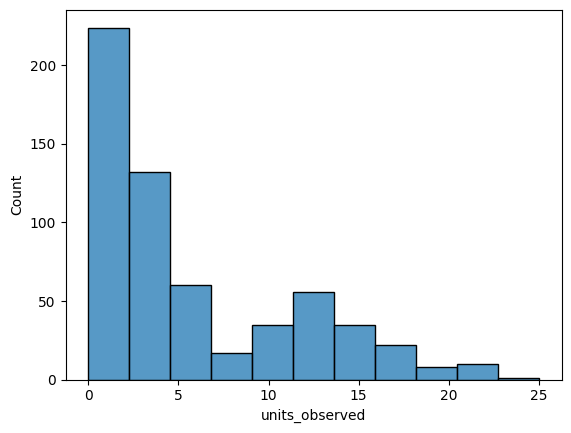

In [24]:
# histogram of racoons observed
sns.histplot(data=df, # choose our dataset
    x='units_observed') # define our y variable

<Axes: xlabel='incidents_of_raccoon_human_standoff', ylabel='Count'>

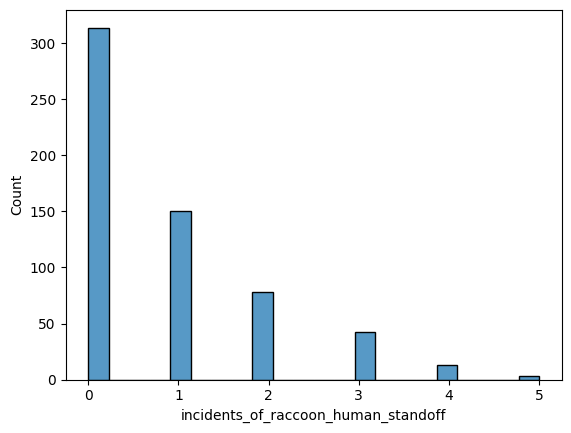

In [26]:
# histogram of raccoon-human standoffs
sns.histplot(data=df, # choose our dataset
    x='incidents_of_raccoon_human_standoff') # define our y variable

<Axes: xlabel='complaints_logged', ylabel='Count'>

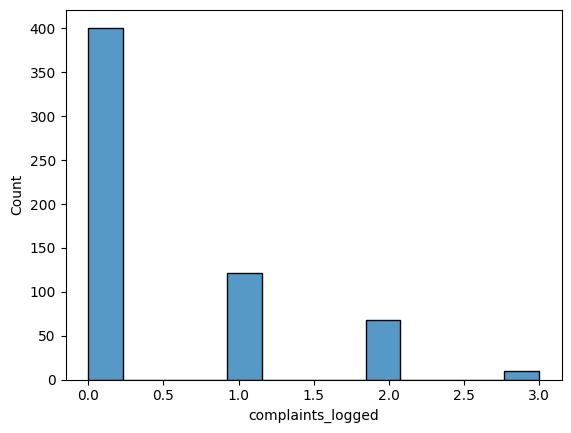

In [27]:
# histogram of complaints logged
sns.histplot(data=df, # choose our dataset
    x='complaints_logged') # define our y variable

In [30]:
# average weight of racoon - testing accuracy
avg_raccoon_weight = df['average_unit_weight_kg'].mean()
print(avg_raccoon_weight)

5.646116666666667


# Creating Visualization

In [31]:
# checking the range of target variables
print(df["complaints_logged"].describe())

count    600.000000
mean       0.478333
std        0.759710
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: complaints_logged, dtype: float64


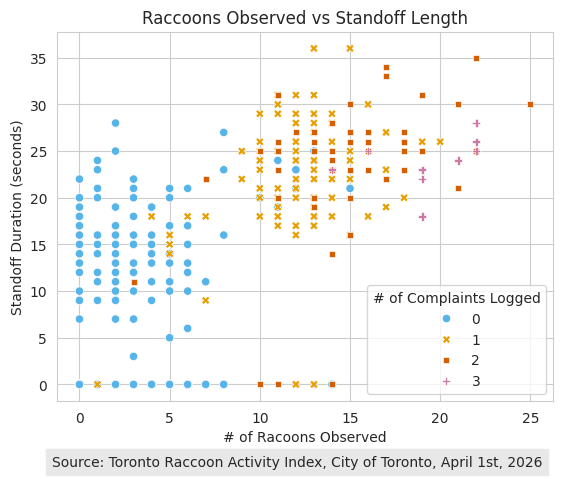

In [59]:
# creating the visualization - looking at trends
sns.set_style('whitegrid')

raccoongraph = sns.scatterplot(data=df,
    x='units_observed',
    y= "avg_standoff_duration_sec",
    style = "complaints_logged",
    hue = "complaints_logged", #setting both a shape and colour for extra accessibility & to show overlap
    #palette = ["purple", 'hotpink', "deepskyblue", 'yellowgreen'] #original palette
    palette = ["#56B4E9", '#E69F00', "#D55E00", '#CC79A7']) #using Okabe-Ito colour-blind friendly palette

# fixing labels
raccoongraph.set(title='Raccoons Observed vs Standoff Length',
    xlabel= '# of Racoons Observed',
    ylabel='Standoff Duration (seconds)')

# set legend title
raccoongraph.legend_.set_title("# of Complaints Logged")

plt.figtext(0.5, -0.025, "Source: Toronto Raccoon Activity Index, City of Toronto, April 1st, 2026", ha="center", fontsize=10, bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})
plt.show()